# Face Mask Detection (4/10/26)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


In [4]:
!pip install split-folders

In [12]:
import splitfolders

## Dividing the Whole Data into Train, Test & Validation

In [14]:
splitfolders.ratio("/kaggle/input/face-mask-dataset/data", ratio=(0.7,0.2,0.1), output="Gun_detection")

Copying files: 7553 files [00:29, 256.92 files/s]


# Preprocessing Images

In [16]:
import tensorflow as tf

In [39]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/Gun_detection/train",
    image_size=(128,128),
    batch_size=32,
    seed=42
)

Found 5286 files belonging to 2 classes.


In [40]:
test_data = tf.keras.utils.image_dataset_from_directory(
    "/content/Gun_detection/test",
    image_size=(128,128),
    batch_size=32,
    seed=42
)

Found 757 files belonging to 2 classes.


In [41]:
val_data = tf.keras.utils.image_dataset_from_directory(
    "/content/Gun_detection/val",
    image_size=(128,128),
    batch_size=32,
    seed=42
)

Found 1510 files belonging to 2 classes.


In [42]:
from PIL import Image
import cv2
from IPython import display

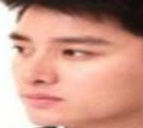

In [43]:
Image.open("/content/Gun_detection/test/without_mask/without_mask_1090.jpg")

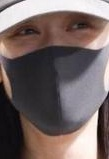

In [44]:
Image.open("/content/Gun_detection/train/with_mask/with_mask_1007.jpg")

array([[[89, 82, 87],
        [68, 62, 67],
        [44, 39, 48],
        ...,
        [26, 28, 28],
        [31, 33, 34],
        [38, 40, 41]],

       [[78, 71, 76],
        [63, 56, 63],
        [52, 47, 56],
        ...,
        [19, 21, 21],
        [24, 26, 27],
        [29, 31, 32]],

       [[76, 68, 75],
        [64, 57, 64],
        [67, 62, 71],
        ...,
        [27, 29, 29],
        [22, 24, 25],
        [23, 25, 26]],

       ...,

       [[23, 25, 33],
        [13, 15, 23],
        [19, 19, 25],
        ...,
        [12, 10, 10],
        [12, 10, 10],
        [13, 11, 11]],

       [[23, 25, 33],
        [13, 15, 23],
        [19, 19, 25],
        ...,
        [13, 11, 11],
        [15, 13, 13],
        [17, 15, 15]],

       [[23, 25, 33],
        [13, 15, 23],
        [19, 19, 25],
        ...,
        [14, 12, 12],
        [15, 13, 13],
        [16, 14, 14]]], dtype=uint8)
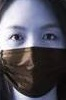

In [45]:
cv2.imread("/content/Gun_detection/train/with_mask/with_mask_1079.jpg")

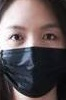

In [46]:
display.Image("/content/Gun_detection/train/with_mask/with_mask_1079.jpg")

In [47]:
from tensorflow import keras
from tensorflow.keras import layers , Sequential

### Neurons Layers Architecture

In [48]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same"), #Feature Extract
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(1, activation="sigmoid") # Output Layer with 1 Output & Sigmoid 0 or 1 Probability


])

In [49]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [50]:
model.fit(train_data, epochs=30, validation_data=val_data)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.5093 - loss: 19.4262 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5068 - loss: 0.6931 - val_

# Gradio:

- Gradio is an open-source Python library that lets you build interactive web interfaces and demos for machine learning models or general Python functions using only Python code.

In [55]:
import numpy as np

In [56]:
import gradio as gr

In [70]:
def predict_image(img):
    img = img.resize((128,128))
    # img = tf.expand_dims(img, 0)
    img = np.expand_dims(np.array(img), axis=0)
    # img_array = tf.keras.utils.img_to_array(images[i].numpy())
    prediction = model.predict(img)[0][0]

    if prediction < 0.5:
      return "Masked"

    else:
      return "No Mask"

app = gr.Interface(fn = predict_image, inputs=gr.Image(type="pil"), outputs="text")

In [72]:
import numpy as np
import gradio as gr

def predict_image(img):
    # Resize image
    img = img.resize((128, 128))

    # Convert to NumPy array
    img = np.array(img, dtype=np.float32)

    # Normalize if your model was trained with images in [0, 1]
    img = img / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Make prediction
    prediction = model.predict(img, verbose=0)[0][0]

    # Convert prediction to class + confidence
    if prediction < 0.5:
        label = "Masked"
        confidence = (1 - prediction) * 100
    else:
        label = "No Mask"
        confidence = prediction * 100

    return f"{label} ({confidence:.2f}% confidence)"


app = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs=gr.Textbox(label="Prediction"),
    title="Face Mask Detection",
    description="Upload an image to determine whether the person is wearing a mask.",
    theme=gr.themes.Soft()
)

app.launch()


/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://892829dcee1adfd154.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [71]:
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://36e84065e0223d8c02.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [73]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [75]:
model = keras.Sequential([
    data_augmentation,

    layers.Rescaling(1./255),
    layers.Conv2D(32, (3,3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same"), #Feature Extract
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(1, activation="sigmoid") # Output Layer with 1 Output & Sigmoid 0 or 1 Probability


])

In [76]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [77]:
model.fit(train_data, epochs=30, validation_data=val_data)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.7719 - loss: 0.5426 - val_accuracy: 0.8543 - val_loss: 0.3255
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8538 - loss: 0.3533 - val_accuracy: 0.8404 - val_loss: 0.3474
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8413 - loss: 0.4033 - val_accuracy: 0.8583 - val_loss: 0.3205
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8583 - loss: 0.3460 - val_accuracy: 0.8695 - val_loss: 0.2896
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8693 - loss: 0.3281 - val_accuracy: 0.8768 - val_loss: 0.2876
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8710 - loss: 0.3142 - val_accuracy: 0.8808 - val_loss: 0.2931
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8712 - loss: 0.3081 - val_accuracy: 0.8815 - val_loss: 0.2961
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8772 - loss: 0.2955 - val_

In [78]:
def predict_image(img):
    img = img.resize((128,128))
    # img = tf.expand_dims(img, 0)
    img = np.expand_dims(np.array(img), axis=0)
    # img_array = tf.keras.utils.img_to_array(images[i].numpy())
    prediction = model.predict(img)[0][0]

    if prediction < 0.5:
      return "Masked"

    else:
      return "No Mask"

app = gr.Interface(fn = predict_image, inputs=gr.Image(type="pil"), outputs="text")

In [79]:
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bcd8a73b15dd5f2e6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [80]:
import shutil

shutil.copytree(
    "/content/Gun_detection",
    "/content/drive/MyDrive/SMIT/Deep Learning/04_Face_Mask_Detection/Gun_detection",
    dirs_exist_ok=True
)


'/content/drive/MyDrive/SMIT/Deep Learning/04_Face_Mask_Detection/Gun_detection'